In [1]:
import numpy as np
import corner
import matplotlib.pyplot as plt
from datetime import datetime
import os
from datetime import datetime
today = datetime.now().strftime("%Y%m%d")


In [13]:
chain = np.load('HMXB_Chain_1_gp_test_chain.npy')
blob = np.load('Kinematic_age_seperation_array_test_chain.npy')
today = datetime.now().strftime("%Y%m%d")

In [3]:
cwd = os.getcwd()
home_files = os.path.dirname(cwd)
home_files = home_files + '/'
mcmc_figures_files  = home_files + 'Figures/MCMC/'
mcmc_figures_files

'/home/karan/Documents/UvA/Thesis/Figures/MCMC/'

In [4]:
print(chain.shape)
nwalkers = len(chain[:,:0])
nwalkers
ndim = chain.shape[2]
ndim
nsteps= 1000

(24, 3000, 4)


In [5]:
print(chain[:, :, 0].min(), chain[:, :, 0].max()) 


1.20520665753283 1.7360349952216523


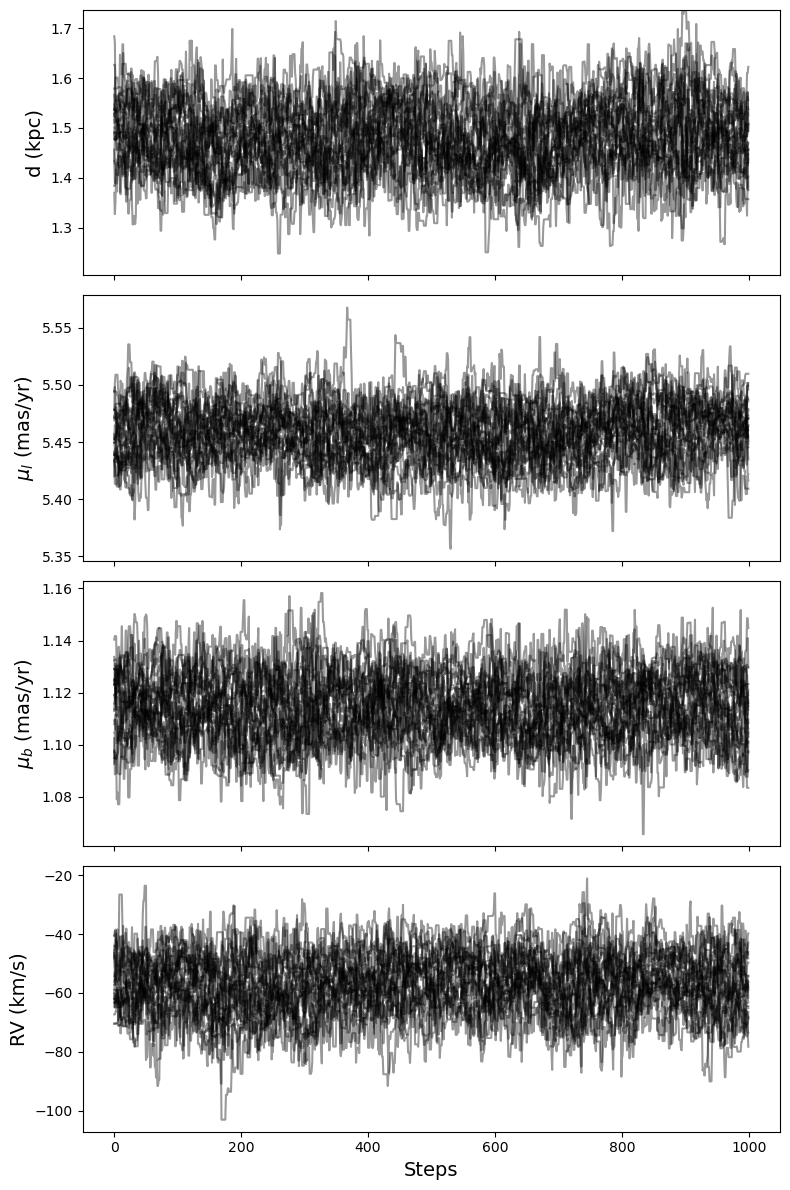

In [6]:
# Plot the trace for each parameter

fig, axes = plt.subplots(ndim, 1, figsize=(8, 12), sharex=True)  # Share x-axis for better alignment
star_labels = ['d (kpc)', r'$\mu_l$ (mas/yr)', r'$\mu_b$ (mas/yr)', 'RV (km/s)']

for j in range(ndim):
    for k in range(nwalkers):
        axes[j].plot(chain[k, :nsteps, j], color='black', alpha=0.4)  # Plot all walkers
    axes[j].set_ylabel(star_labels[j], fontsize=14)
    axes[j].ticklabel_format(style='plain', axis='y')
    axes[0].set_ylim(chain[:, :, 0].min(), chain[:, :, 0].max())

axes[-1].set_xlabel('Steps', fontsize=14)
plt.tight_layout()
plt.savefig(mcmc_figures_files+f'gauss_prior_chains_{today}.png')
plt.show()





(7200, 2)


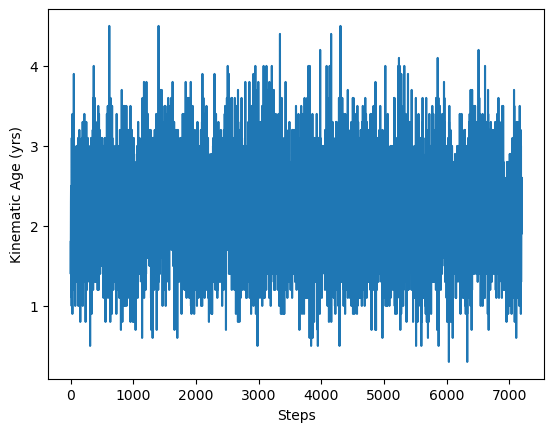

In [15]:
kinematic_ages = np.array([b[0] for b in blob])
min_separations = np.array([b[1] for b in blob])

plt.plot(kinematic_ages,label='blob')
print(blob.shape)
plt.ylabel('Kinematic Age (yrs)')
plt.xlabel('Steps')
plt.savefig(mcmc_figures_files+f'Kinematic_age_blob_gauss_prior_{today}.png')
plt.show()

(7200, 2)


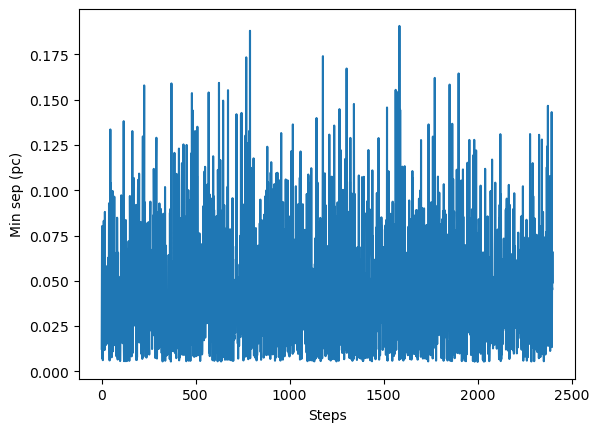

In [14]:
plt.plot(min_separations,label='blob')
print(blob.shape)
plt.ylabel('Min sep (pc)')
plt.xlabel('Steps')
plt.savefig(mcmc_figures_files+f'Min_sep_blob_gauss_prior_{today}.png')
plt.show()

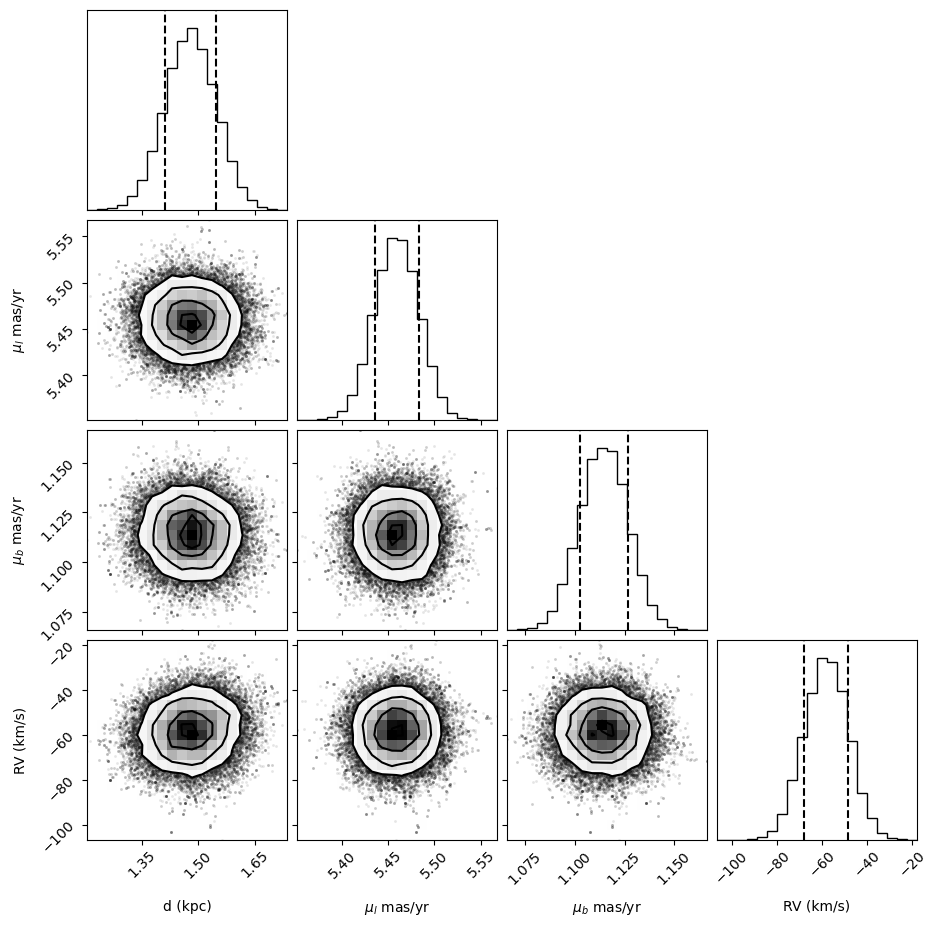

In [9]:

# Assuming chain is of shape (num_iterations, num_parameters)
star_labels = ['d (kpc)', r'$\mu_l$ mas/yr', r'$\mu_b$ mas/yr', 'RV (km/s)']

corner.corner(chain, labels=star_labels,quantiles=(0.16, 0.84),color='xkcd:black',use_math_text=True)
plt.savefig(mcmc_figures_files+f'corner_gauss_prior_{today}.png')
plt.show()

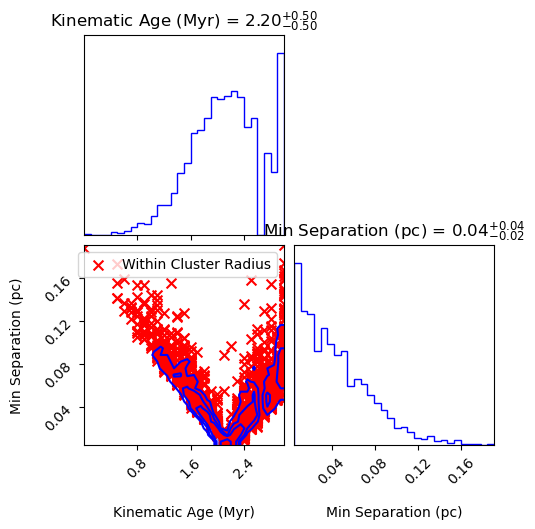

In [10]:

def plot_blob_corner(blob_file, cluster_radius):
    """
    Load blob data from an .npy file, extract kinematic age and minimum separation,
    and create a corner plot highlighting samples with min separation within the cluster radius.
    
    Parameters
    ----------
    blob_file : str
        Path to the .npy file containing the blob data from MCMC.
    cluster_radius : float
        Cluster radius (in the same units as the minimum separation, e.g., kpc) used to highlight samples.
    
    Returns
    -------
    None
    """
    # Load the blob data; allow_pickle=True because blobs may be stored as tuples or lists.
    blobs = np.load(blob_file, allow_pickle=True)
    
    # Initialize lists to store kinematic ages and min separations.
    kinematic_ages = []
    min_separations = []
    
    # Loop through each blob in the loaded array.
    # Assume each blob is a tuple (kinematic_age, min_sep) or list with at least two elements.
    for b in blobs:
        if isinstance(b, (tuple, list, np.ndarray)) and len(b) >= 2:
            kin_age, min_sep = b[0], b[1]
            kinematic_ages.append(kin_age)
            min_separations.append(min_sep)
        else:
            continue
    
    # Convert lists to numpy arrays
    kinematic_ages = np.array(kinematic_ages)
    min_separations = np.array(min_separations)
    
    # Stack the two arrays into a single 2D array (each row is a sample: [kin_age, min_sep])
    data = np.vstack([kinematic_ages, min_separations]).T
    
    # Create a mask for samples with minimum separation within the cluster radius
    highlight_mask = min_separations <= cluster_radius
    data_highlight = data[highlight_mask]
    
    # Generate the corner plot
    fig = corner.corner(
        data,
        labels=["Kinematic Age (Myr)", "Min Separation (pc)"],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        plot_datapoints=True,
        bins=30,
        color='blue'
    )
    
    # For a two-parameter corner plot, the scatter plot is usually in the lower left panel.
    # Get the appropriate axis and overlay the highlighted points.
    # Since corner returns a flat list of axes, we must determine which one is the scatter plot.
    # For two parameters, axes[2] is typically the scatter plot.
    ax_scatter = fig.axes[2]
    ax_scatter.scatter(data_highlight[:, 0], data_highlight[:, 1],
                       color='red', marker='x', s=50, label="Within Cluster Radius")
    ax_scatter.legend()
    
    plt.show()

# Example usage:
plot_blob_corner("Kinematic_age_min_sep_gp_test_chain.npy", cluster_radius=1.0)


7200
[[1.8]
 [1.4]
 [2. ]
 ...
 [2.6]
 [1.9]
 [2.6]]


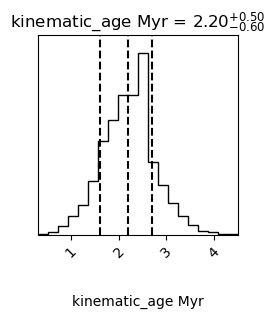

In [16]:

blobs_2d = kinematic_ages[:, None]  # reshape to (n_samples, 1)
print(len(blobs_2d))
print(blobs_2d)
fig = corner.corner(blobs_2d, labels=["kinematic_age Myr"],quantiles=(0.16,0.5, 0.84),show_titles=True,use_math_text=True,fill_contours=True)
plt.savefig(mcmc_figures_files+f'kin_age_corner_gauss_prior_{today}.png')
plt.show()

7200
[[0.04265452]
 [0.06805411]
 [0.01522332]
 ...
 [0.04198425]
 [0.05041093]
 [0.04584587]]


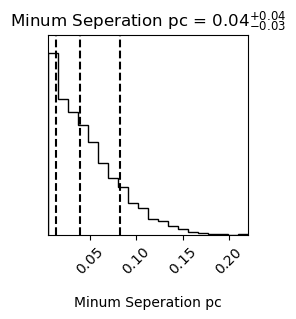

In [17]:
blobs_2d = min_separations[:, None]  # reshape to (n_samples, 1)
print(len(blobs_2d))
print(blobs_2d)
fig = corner.corner(blobs_2d, labels=["Minum Seperation pc"],quantiles=(0.16,0.5, 0.84),show_titles=True,use_math_text=True,fill_contours=True)
plt.savefig(mcmc_figures_files+f'min_sep_corner_gauss_prior_{today}.png')
plt.show()

In [26]:
print(blob.shape)

(2400, 2)


# 170037 with UBC 323

In [18]:
chain_1737_ubc323 = np.load("Chain_170037_ubc323.npy")
#store blob
blob_1737_ubc323 = np.load("Kinematic_age_blob_170037_ubc323.npy")

In [20]:
chain_1737_ubc323

array([[[347.74577567,   2.16853068,   1.59655989,   5.40015936,
           1.10311426, -47.84472854],
        [347.74577567,   2.16853068,   1.59655989,   5.40015936,
           1.10311426, -47.84472854],
        [347.74489507,   2.16808427,   1.59483419,   5.39887425,
           1.10270402, -47.69235427],
        ...,
        [347.7624404 ,   2.17324499,   1.51469254,   5.46478001,
           1.10764348, -45.45970013],
        [347.75573592,   2.17122472,   1.47066913,   5.46127033,
           1.10360309, -44.17867287],
        [347.75609223,   2.17337625,   1.50775567,   5.45972751,
           1.10843406, -56.66906904]],

       [[347.77509438,   2.17429665,   1.53662395,   5.45617631,
           1.10006259, -51.03101143],
        [347.7736636 ,   2.17448767,   1.54231638,   5.45931714,
           1.10275235, -50.85063736],
        [347.77609419,   2.17420875,   1.55121005,   5.45550878,
           1.1041775 , -49.09341141],
        ...,
        [347.77696665,   2.16611248,   1.4476

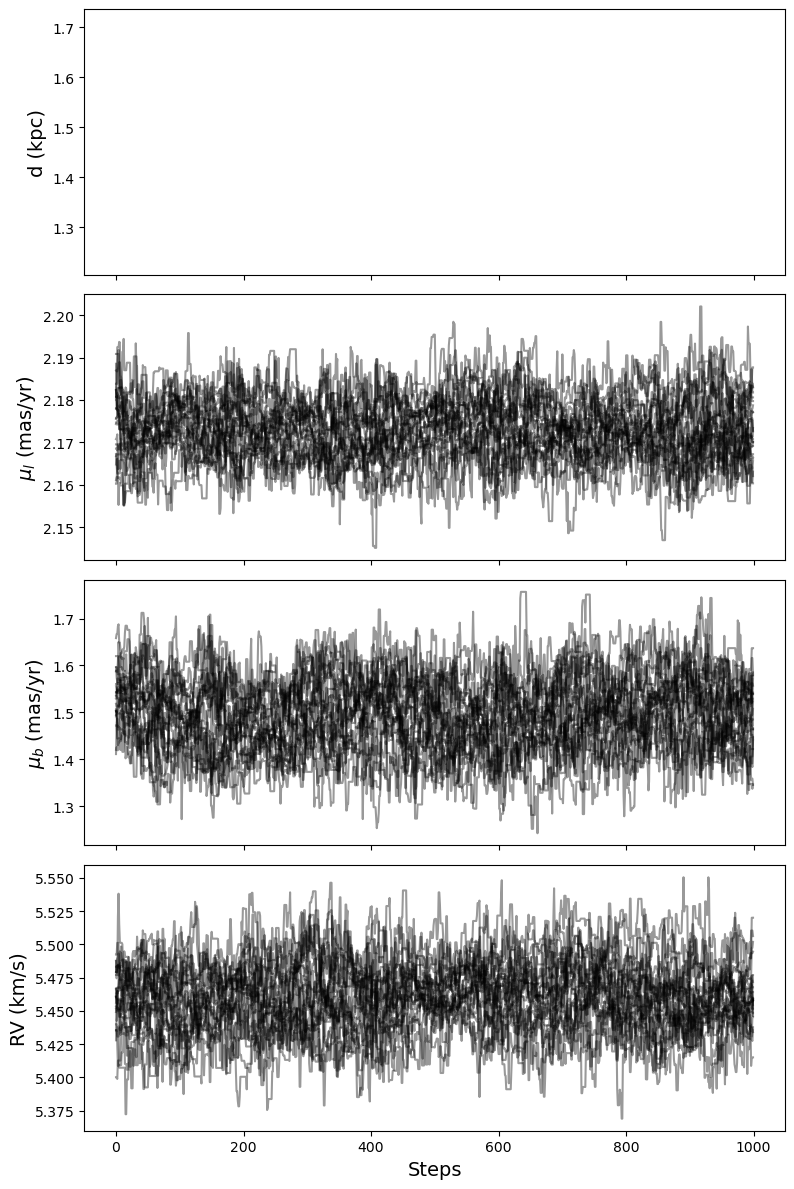

In [24]:

fig, axes = plt.subplots(ndim, 1, figsize=(8, 12), sharex=True)  # Share x-axis for better alignment
star_labels = ['d (kpc)', r'$\mu_l$ (mas/yr)', r'$\mu_b$ (mas/yr)', 'RV (km/s)']

for j in range(ndim):
    for k in range(nwalkers):
        axes[j].plot(chain_1737_ubc323[k, :nsteps, j], color='black', alpha=0.4)  # Plot all walkers
    axes[j].set_ylabel(star_labels[j], fontsize=14)
    axes[j].ticklabel_format(style='plain', axis='y')
    axes[0].set_ylim(chain[:, :, 0].min(), chain[:, :, 0].max())

axes[-1].set_xlabel('Steps', fontsize=14)
plt.tight_layout()
plt.savefig(mcmc_figures_files+'chains_170037_ubc323.png')
plt.show()


(2400,)


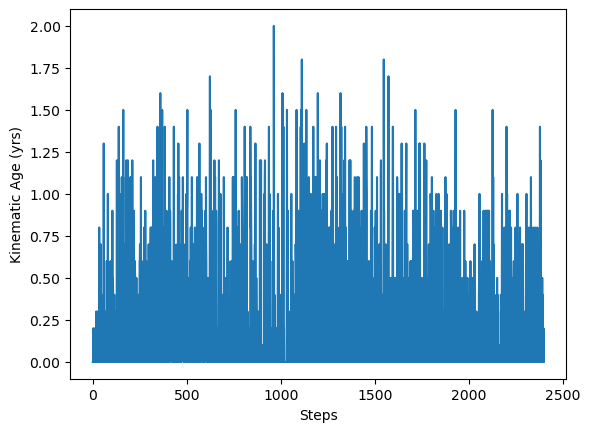

In [29]:
plt.plot(blob_1737_ubc323,label='blob')
print(blob_1737_ubc323.shape)
plt.ylabel('Kinematic Age (yrs)')
plt.xlabel('Steps')
plt.savefig(mcmc_figures_files+'Kinematic_age_blob_170037_ubc323.png')
plt.show()

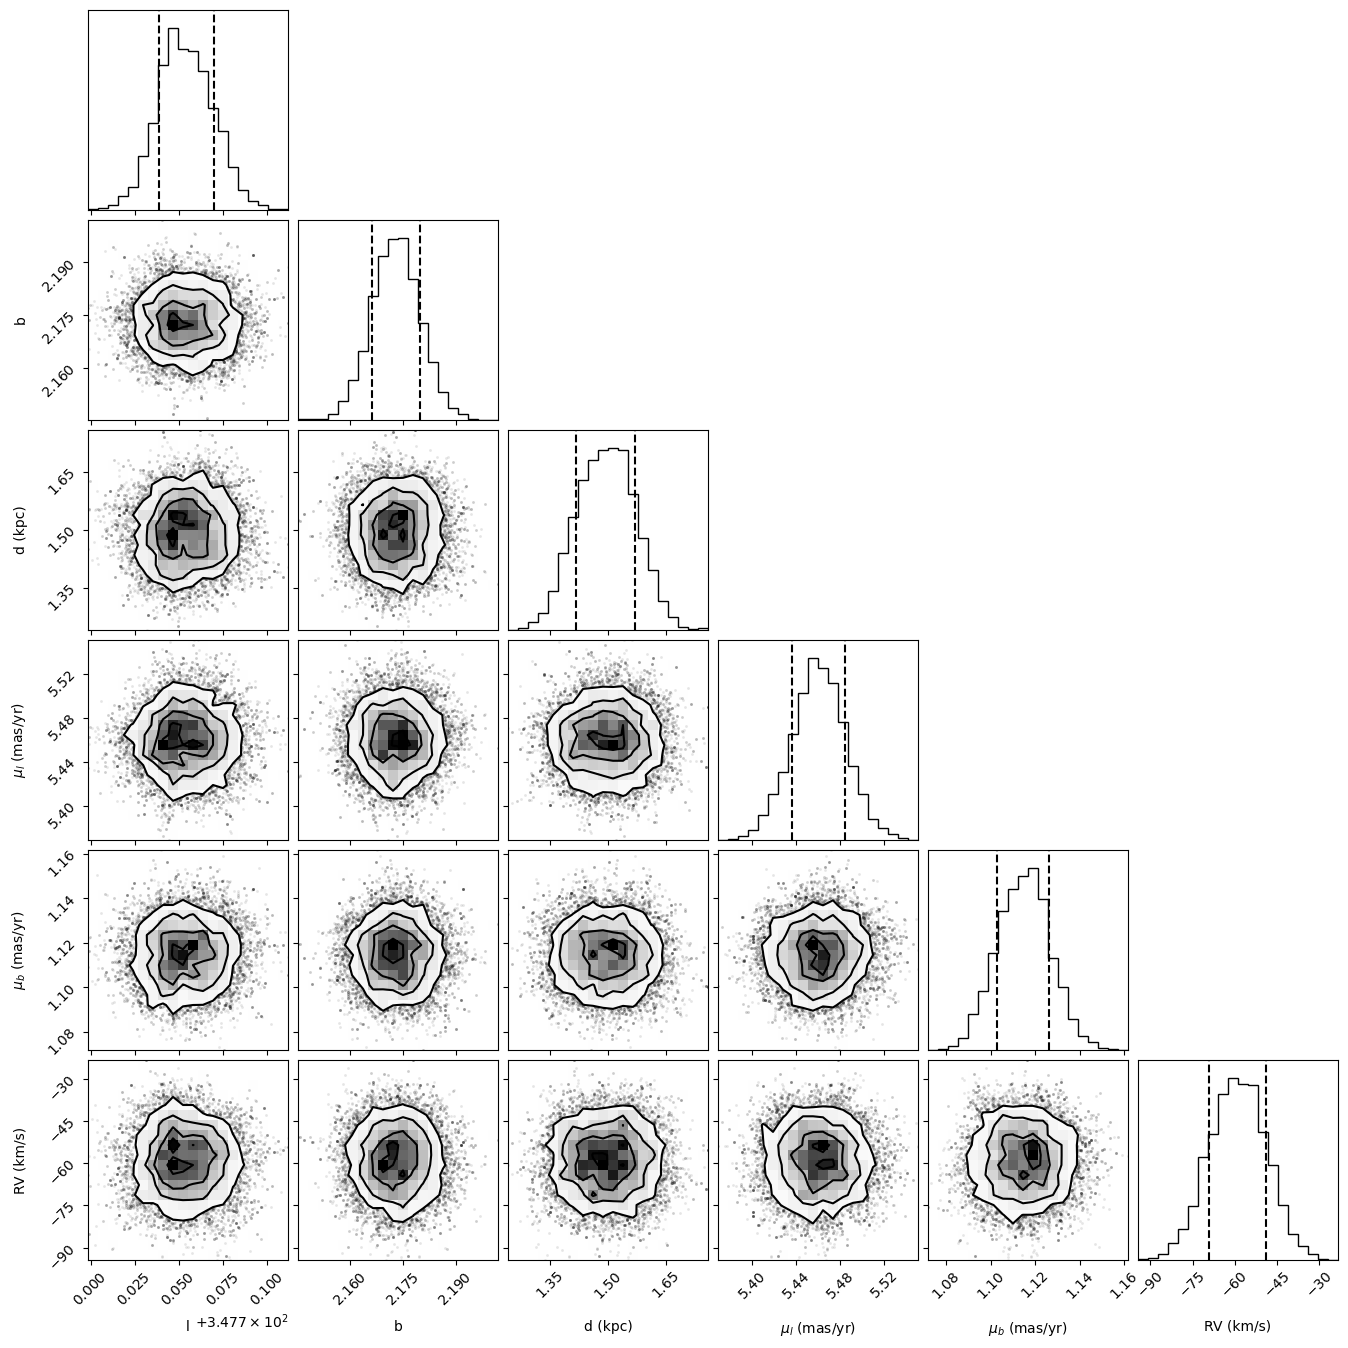

In [30]:
corner.corner(chain_1737_ubc323, labels=star_labels,quantiles=(0.16, 0.84),color='xkcd:black',use_math_text=True)
plt.savefig(mcmc_figures_files+'corner_ubc323.png')
plt.show()

2400
[[-0. ]
 [-0. ]
 [ 0.2]
 ...
 [-0. ]
 [ 0.2]
 [-0. ]]


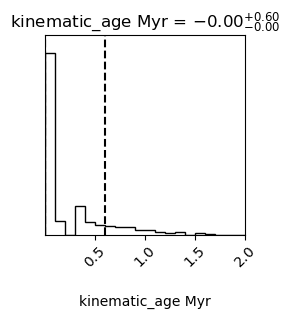

In [31]:
blobs_2d = blob_1737_ubc323[:, None]  # reshape to (n_samples, 1)
print(len(blobs_2d))
print(blobs_2d)
fig = corner.corner(blobs_2d, labels=["kinematic_age Myr"],quantiles=(0.16,0.5, 0.84),show_titles=True,use_math_text=True,fill_contours=True)
plt.savefig(mcmc_figures_files+'kin_age_corner_ubc323.png')
plt.show()

# A Test Case with 170037 and cep ob1 to see if it will fail

In [32]:
chain_1737_cep = np.load("Chain_170037_cepob1.npy")
#store blob
blob_1737_cep = np.load("Kinematic_age_blob_170037_cepob1.npy")

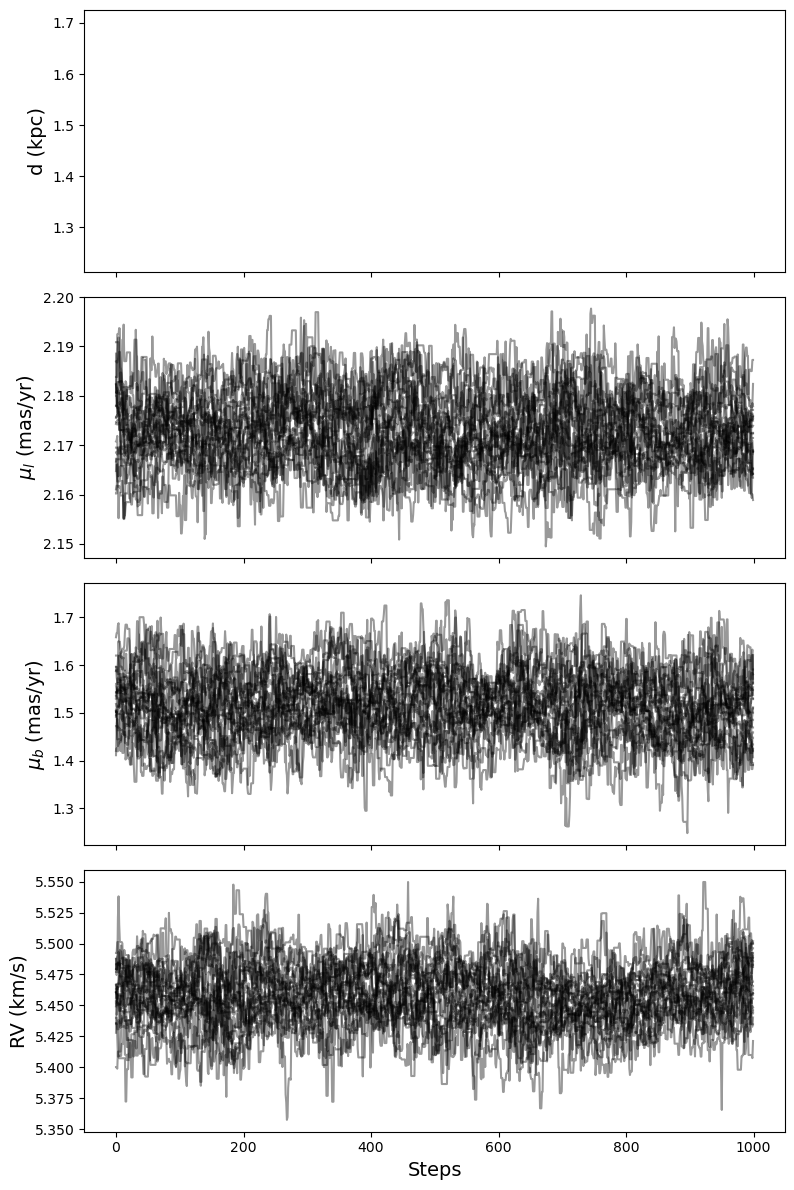

In [38]:

fig, axes = plt.subplots(ndim, 1, figsize=(8, 12), sharex=True)  # Share x-axis for better alignment
star_labels = ['d (kpc)', r'$\mu_l$ (mas/yr)', r'$\mu_b$ (mas/yr)', 'RV (km/s)']

for j in range(ndim):
    for k in range(nwalkers):
        axes[j].plot(chain_1737_cep[k, :nsteps, j], color='black', alpha=0.4)  # Plot all walkers
    axes[j].set_ylabel(star_labels[j], fontsize=14)
    axes[j].ticklabel_format(style='plain', axis='y')
    axes[0].set_ylim(chain[:, :, 0].min(), chain[:, :, 0].max())

axes[-1].set_xlabel('Steps', fontsize=14)
plt.tight_layout()
plt.savefig(mcmc_figures_files+f'chains_170037_cepob1_{today}.png')
plt.show()


(7200,)


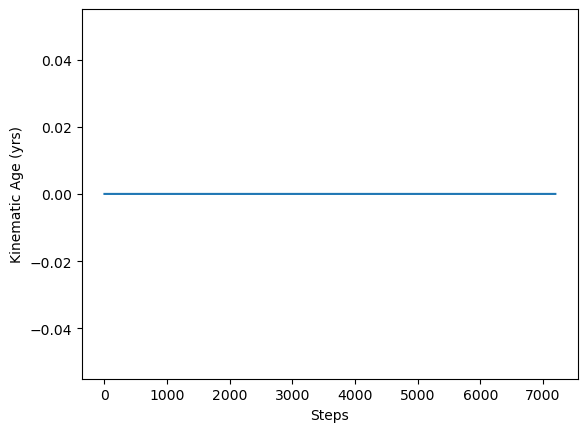

In [34]:
plt.plot(blob_1737_cep,label='blob')
print(blob_1737_cep.shape)
plt.ylabel('Kinematic Age (yrs)')
plt.xlabel('Steps')
plt.savefig(mcmc_figures_files+f'Kinematic_age_blob_170037_cepob1_{today}.png')

plt.show()

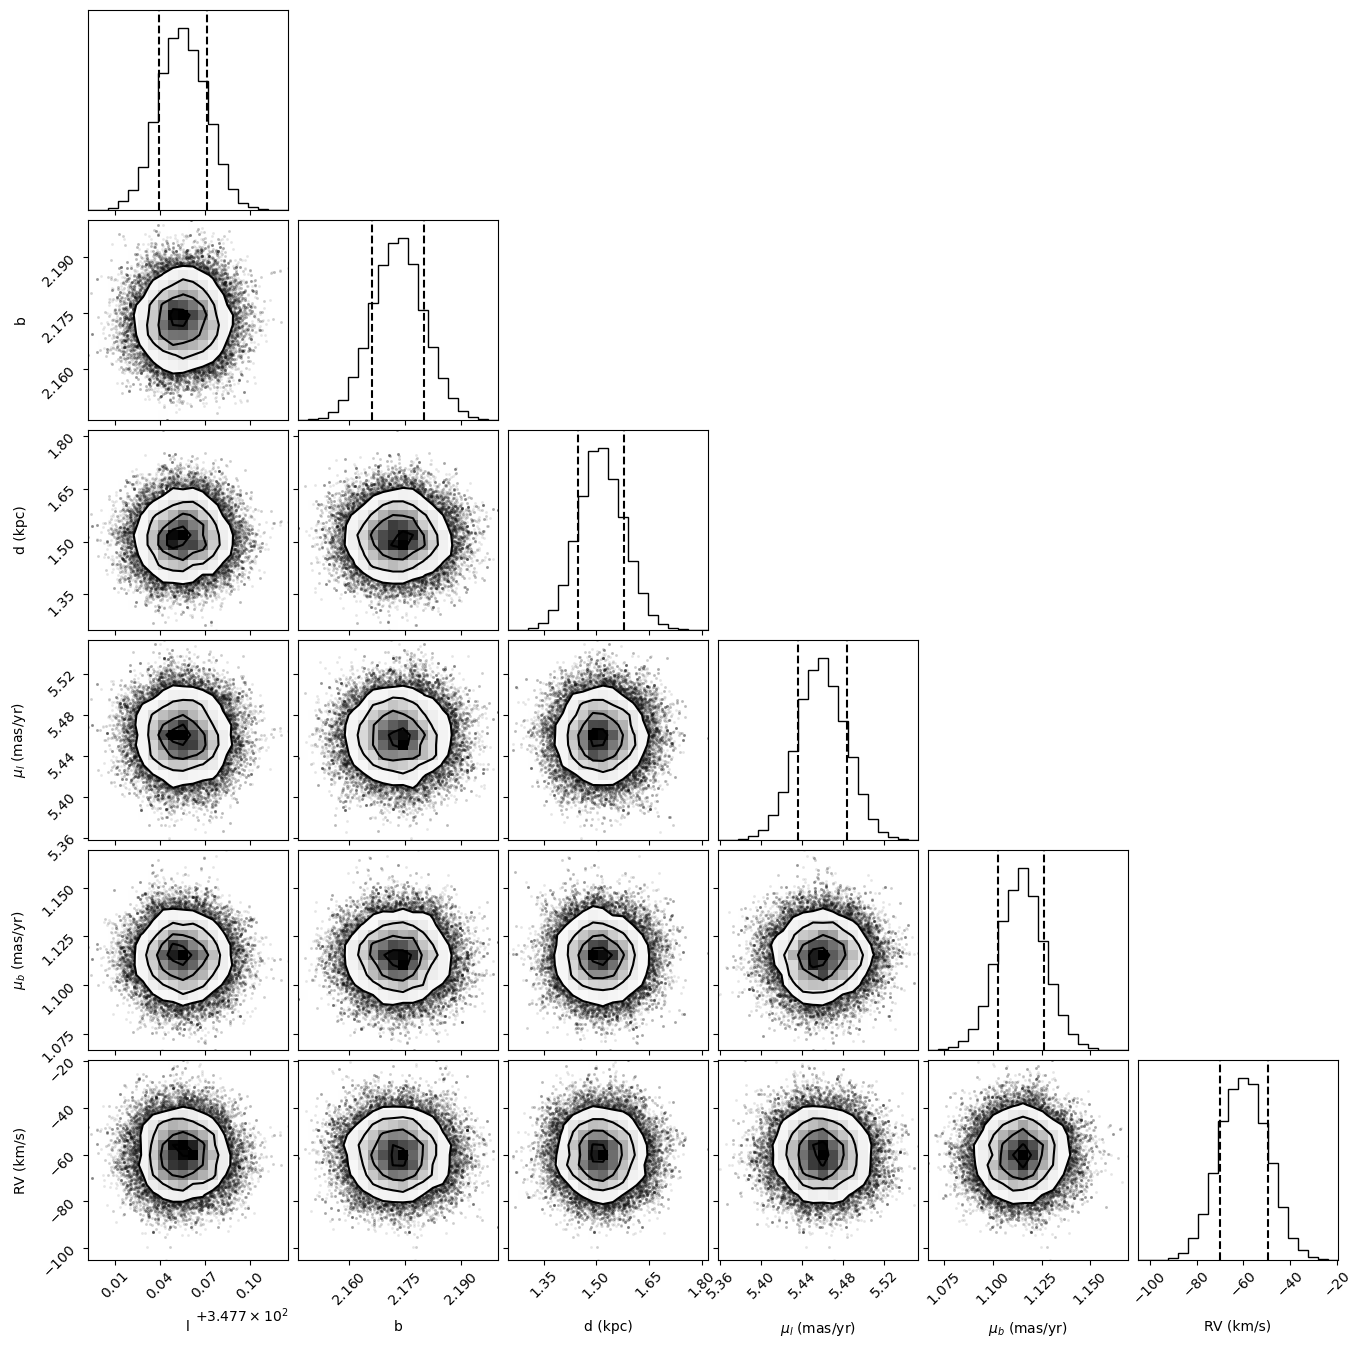

In [35]:
corner.corner(chain_1737_cep, labels=star_labels,quantiles=(0.16, 0.84),color='xkcd:black',use_math_text=True)
plt.savefig(mcmc_figures_files+f'corner_cepob1_{today}.png')
plt.show()

7200
[[-0.]
 [-0.]
 [-0.]
 ...
 [-0.]
 [-0.]
 [-0.]]


ValueError: It looks like the parameter(s) in column(s) 0 have no dynamic range. Please provide a `range` argument.

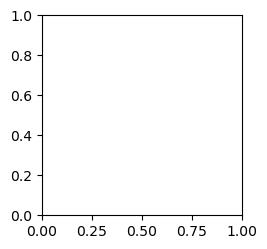

In [36]:
blobs_2d = blob_1737_cep[:, None]  # reshape to (n_samples, 1)
print(len(blobs_2d))
print(blobs_2d)
fig = corner.corner(blobs_2d, labels=["kinematic_age Myr"],quantiles=(0.16,0.5, 0.84),show_titles=True,use_math_text=True,fill_contours=True)
plt.savefig(mcmc_figures_files+'kin_age_corner_gauss_prior.png')
plt.show()